# Dataloader visualization

In [13]:
import json
import yaml
import matplotlib.pyplot as plt
import numpy as np

from utils import TacArenaDataset, get_norm_stats

In [14]:
import h5py, os

# Load task config
with open("SIM_TASK_CONFIGS.json", "r") as f:
    SIM_TASK_CONFIGS = json.load(f)

task_name = list(SIM_TASK_CONFIGS.keys())[0]
task_config = SIM_TASK_CONFIGS[task_name]
dataset_dir  = task_config["dataset_dir"]
num_episodes = task_config["num_episodes"]

with open("train_config_all.yml", "r") as f:
    train_cfg = yaml.safe_load(f)

chunk_size = train_cfg["chunk_size"]

# Check what keys are actually present in the first episode
with h5py.File(os.path.join(dataset_dir, "episode_0.hdf5"), "r") as f:
    available_images = set(f["/observations/images"].keys())
print(f"Available image keys in HDF5: {available_images}")

camera_names  = [c for c in train_cfg["camera_names"]  if c in available_images]
tactile_names = [t for t in train_cfg["tactile_names"] if t in available_images]

skipped = [c for c in train_cfg["camera_names"] if c not in available_images]
if skipped:
    print(f"Warning: skipping cameras not found in dataset: {skipped}")

print(f"Cameras : {camera_names}")
print(f"Tactile : {tactile_names}")

Available image keys in HDF5: {'tac_left', 'cam_high', 'tac_right'}
Cameras : ['cam_high']
Tactile : ['tac_left', 'tac_right']


In [15]:
norm_stats, _ = get_norm_stats(dataset_dir, num_episodes)

dataset = TacArenaDataset(
    episode_ids=list(range(num_episodes)),
    dataset_dir=dataset_dir,
    camera_names=camera_names,
    tactile_names=tactile_names,
    norm_stats=norm_stats,
    chunk_size=chunk_size,
)
print(f"Dataset size: {len(dataset)} samples")

Dataset size: 30432 samples


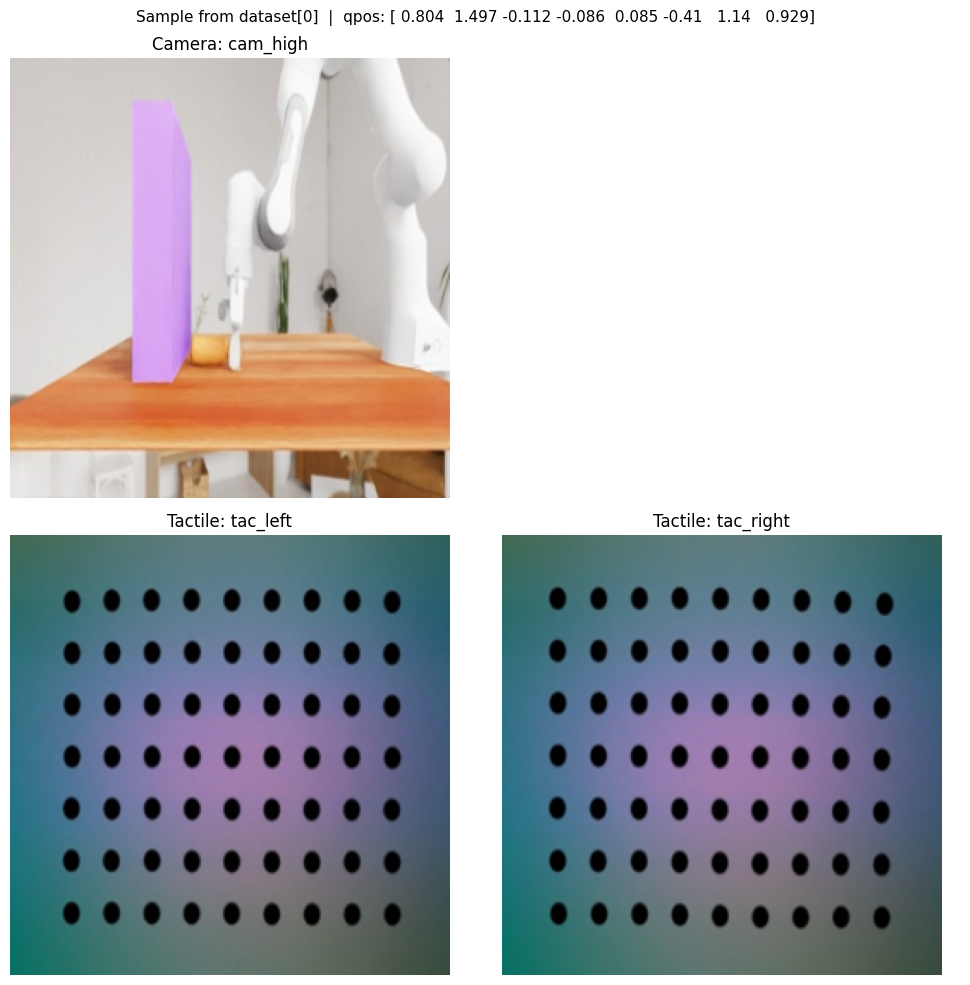

In [16]:
cam_images, tac_images, qpos, actions, is_pad = dataset[0]
# cam_images: (num_cameras, 3, H, W) — normalized
# tac_images: (num_tactile, 3, H, W) — raw [0,1]

n_cams = cam_images.shape[0]
n_tacs = tac_images.shape[0]
n_cols = max(n_cams, n_tacs)

fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 10))
if n_cols == 1:
    axes = axes.reshape(2, 1)

# --- RGB cameras (denormalize for display) ---
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
for i in range(n_cams):
    img = cam_images[i].numpy().transpose(1, 2, 0)  # CHW -> HWC
    img = (img * std + mean).clip(0, 1)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Camera: {camera_names[i]}")
    axes[0, i].axis("off")
for i in range(n_cams, n_cols):
    axes[0, i].axis("off")

# --- Tactile images ---
for i in range(n_tacs):
    img = tac_images[i].numpy().transpose(1, 2, 0).clip(0, 1)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Tactile: {tactile_names[i]}")
    axes[1, i].axis("off")
for i in range(n_tacs, n_cols):
    axes[1, i].axis("off")

plt.suptitle(f"Sample from dataset[0]  |  qpos: {qpos.numpy().round(3)}", fontsize=11)
plt.tight_layout()
plt.show()